# Задача на Препроцессинг данных и Линейную регрессию

 Дан датасет **California Housing** и стоит задача предсказать медианную стоимость дома в жилом блоке (block group) на основе демографических и географических признаков

## **1.** Подготовка данных и исследовательский анализ

### **1.0.** Загрузка библиотек и дадасета

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import LinearRegression

In [2]:
data = pd.DataFrame(fetch_california_housing().data)
data.columns = fetch_california_housing().feature_names
data["MedHouseVal"] = fetch_california_housing().target

In [3]:
fetch_california_housing().DESCR

'.. _california_housing_dataset:\n\nCalifornia Housing dataset\n--------------------------\n\n**Data Set Characteristics:**\n\n:Number of Instances: 20640\n\n:Number of Attributes: 8 numeric, predictive attributes and the target\n\n:Attribute Information:\n    - MedInc        median income in block group\n    - HouseAge      median house age in block group\n    - AveRooms      average number of rooms per household\n    - AveBedrms     average number of bedrooms per household\n    - Population    block group population\n    - AveOccup      average number of household members\n    - Latitude      block group latitude\n    - Longitude     block group longitude\n\n:Missing Attribute Values: None\n\nThis dataset was obtained from the StatLib repository.\nhttps://www.dcc.fc.up.pt/~ltorgo/Regression/cal_housing.html\n\nThe target variable is the median house value for California districts,\nexpressed in hundreds of thousands of dollars ($100,000).\n\nThis dataset was derived from the 1990 U.S

In [4]:
data

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422
...,...,...,...,...,...,...,...,...,...
20635,1.5603,25.0,5.045455,1.133333,845.0,2.560606,39.48,-121.09,0.781
20636,2.5568,18.0,6.114035,1.315789,356.0,3.122807,39.49,-121.21,0.771
20637,1.7000,17.0,5.205543,1.120092,1007.0,2.325635,39.43,-121.22,0.923
20638,1.8672,18.0,5.329513,1.171920,741.0,2.123209,39.43,-121.32,0.847


### **1.1.** Исследовательский анализ, выдвижение гипотез 

In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


In [6]:
data.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


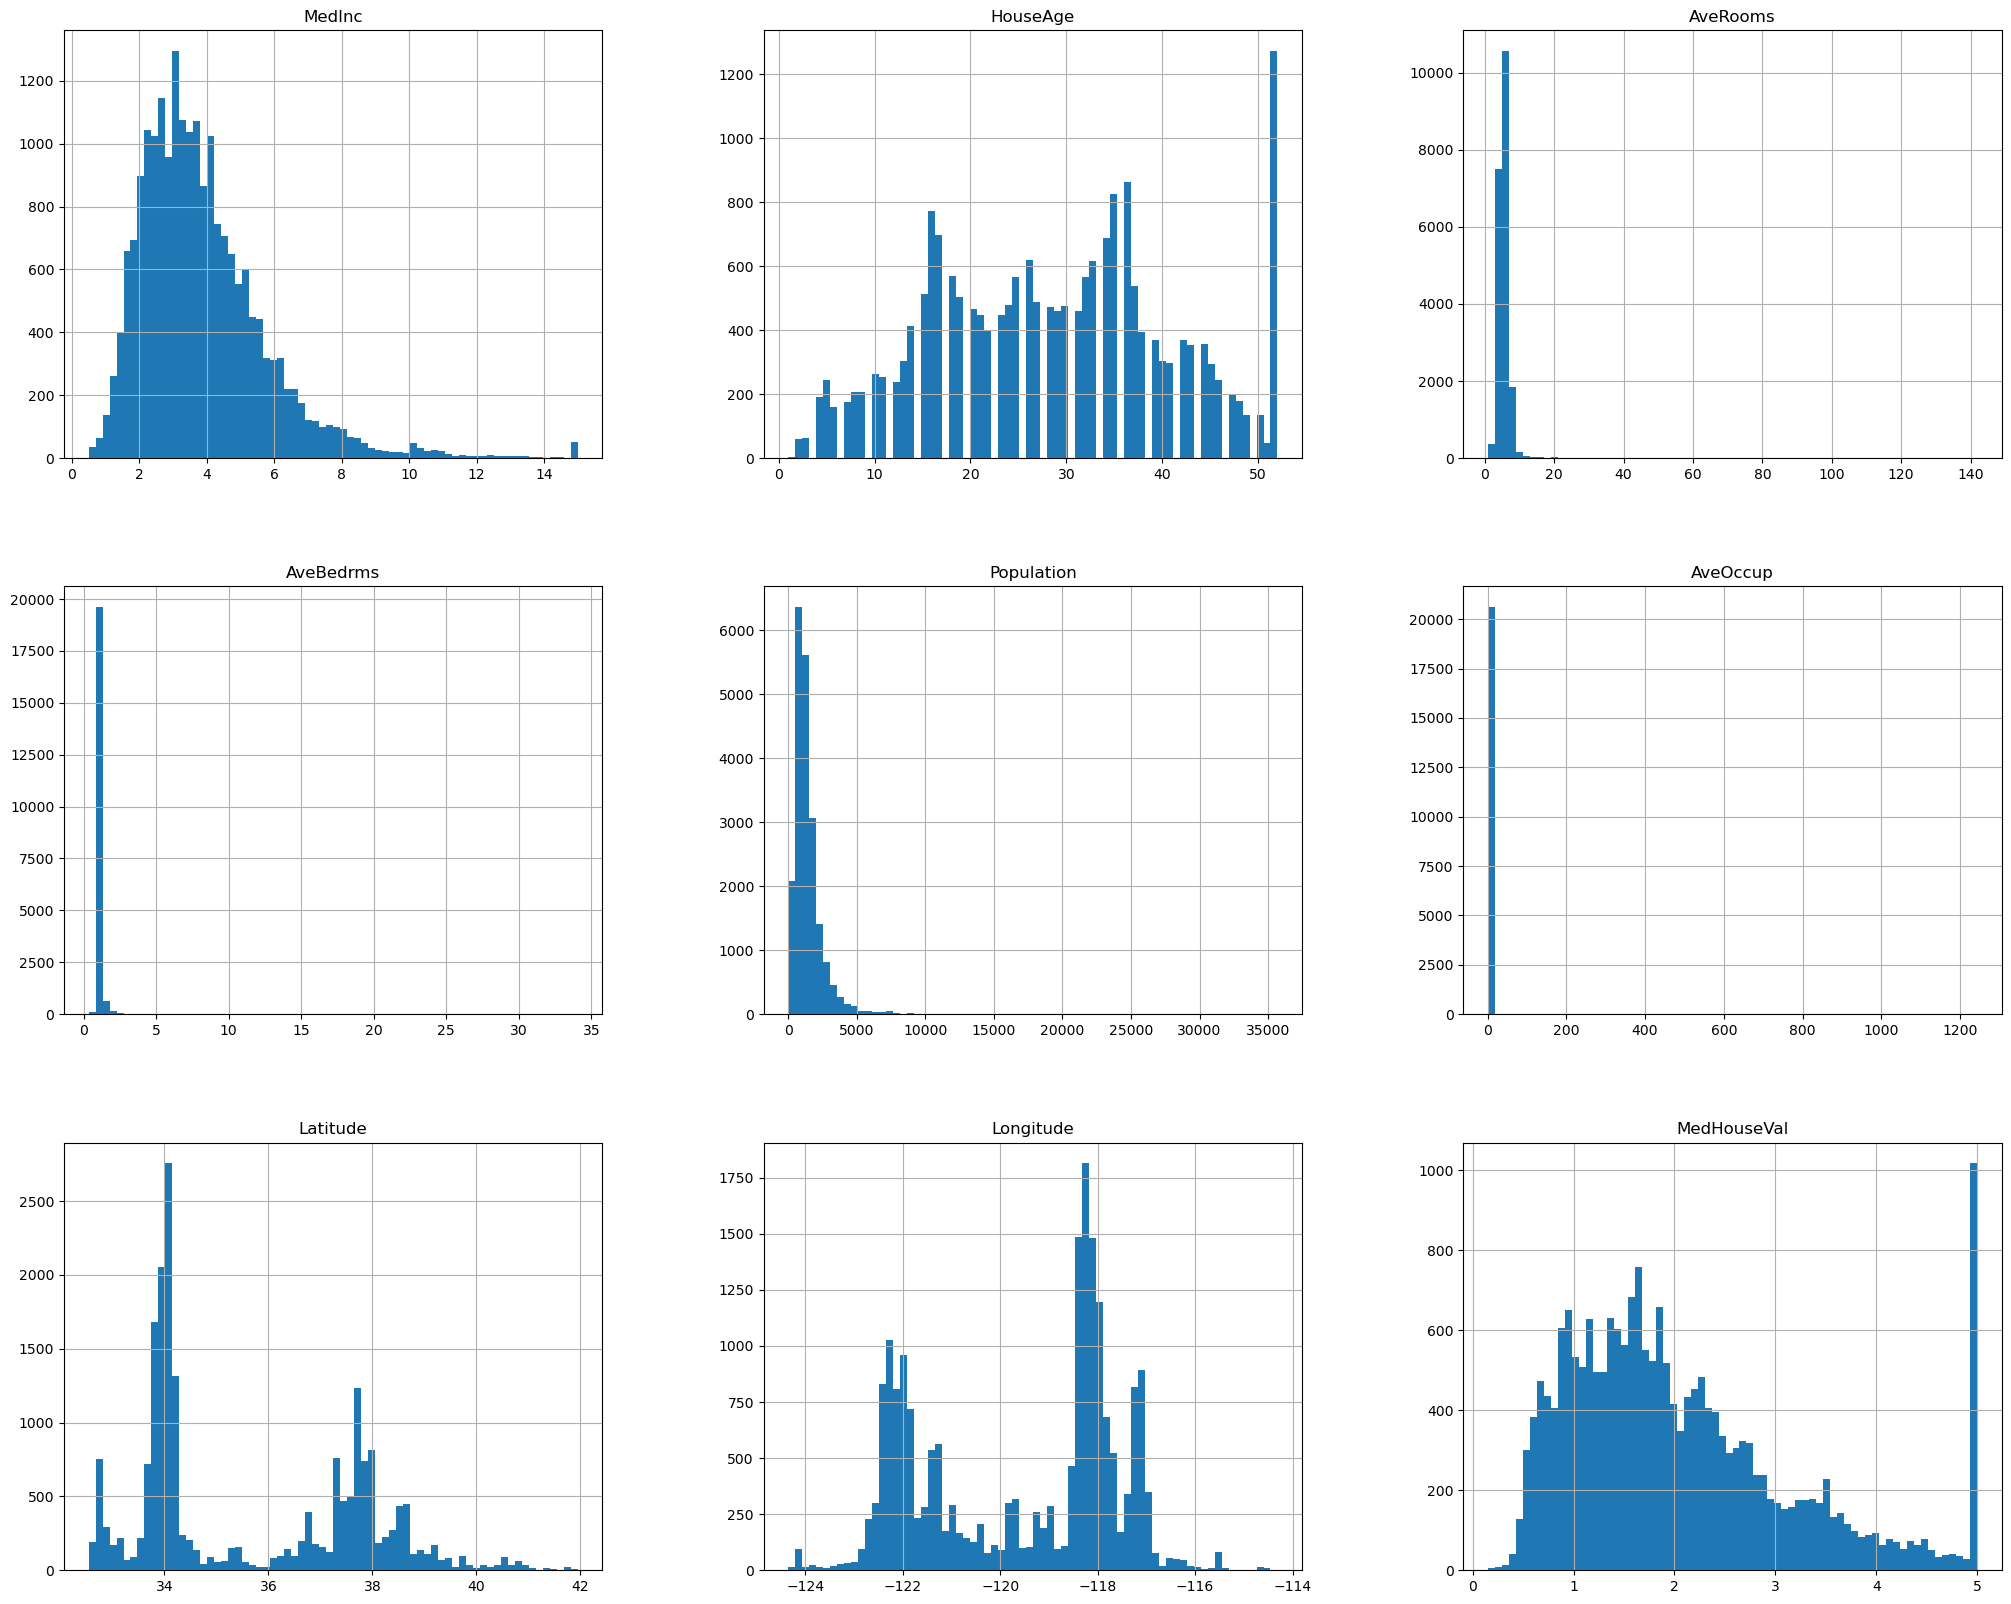

In [7]:
data.hist(bins = 70, figsize = (25,20))
plt.show()

In [8]:
data.duplicated().sum()

np.int64(0)

In [9]:
data.drop_duplicates(inplace = True)

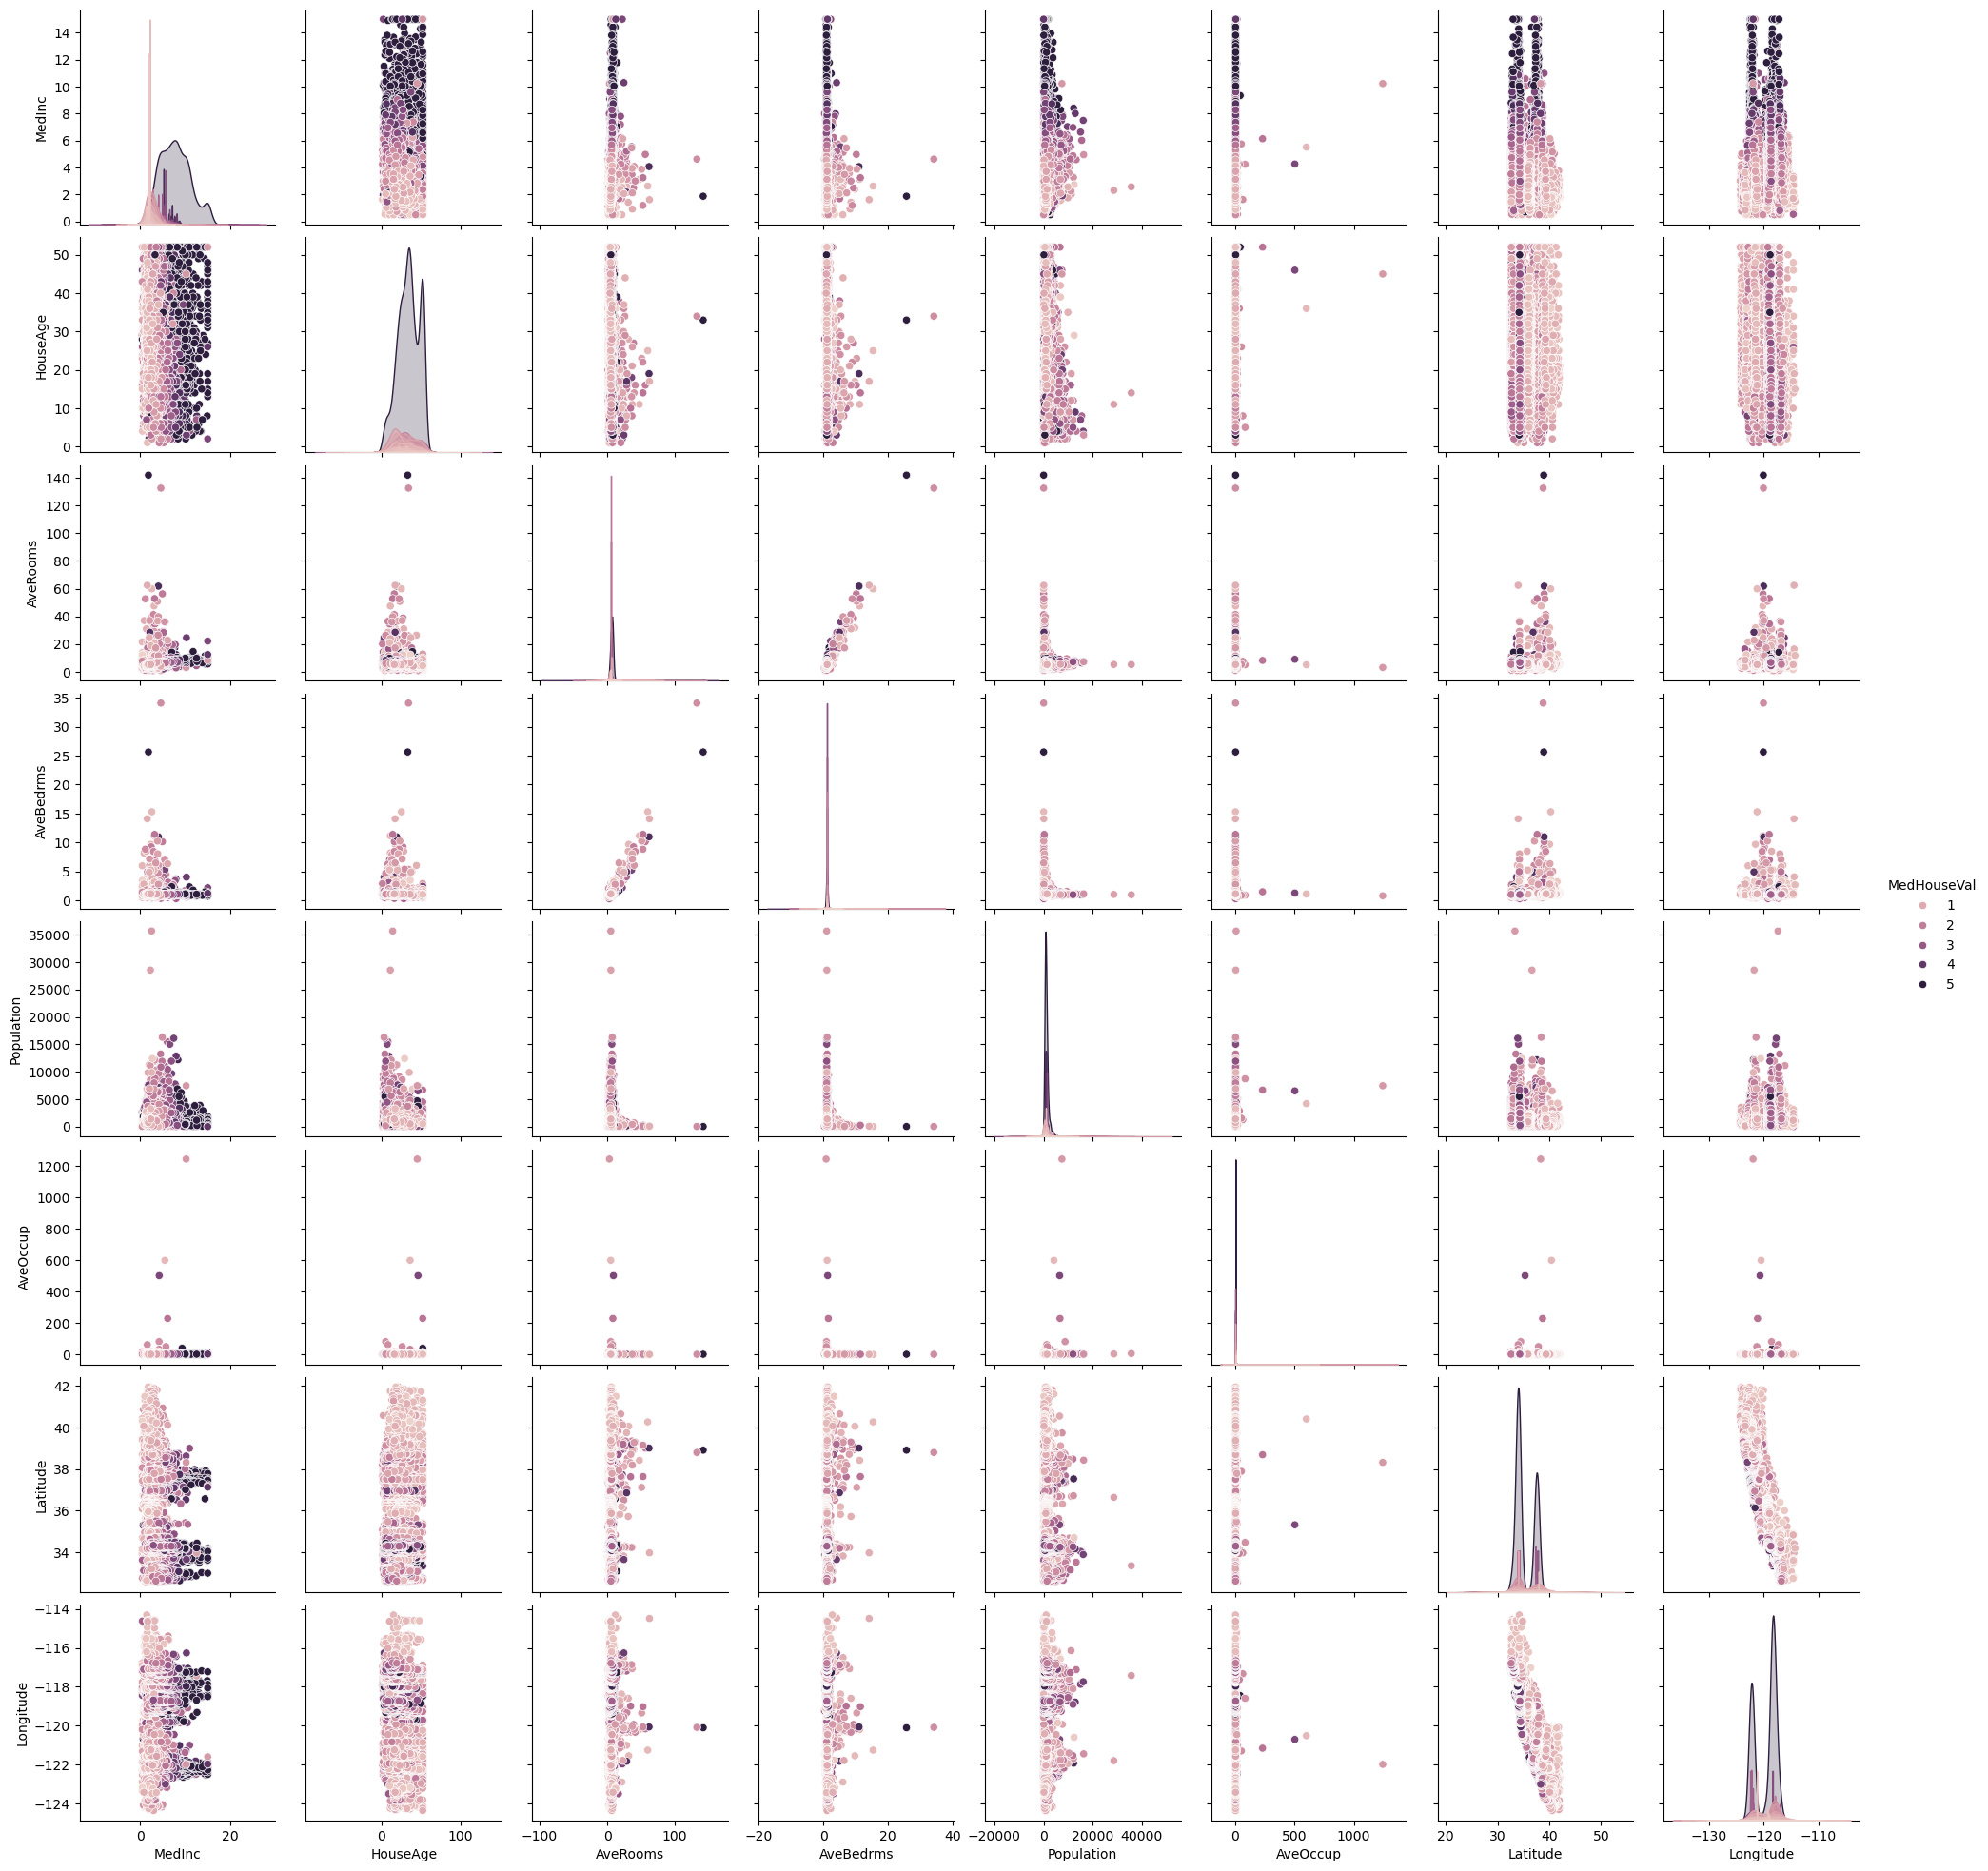

In [10]:
sns.pairplot(data, hue='MedHouseVal')
plt.show()

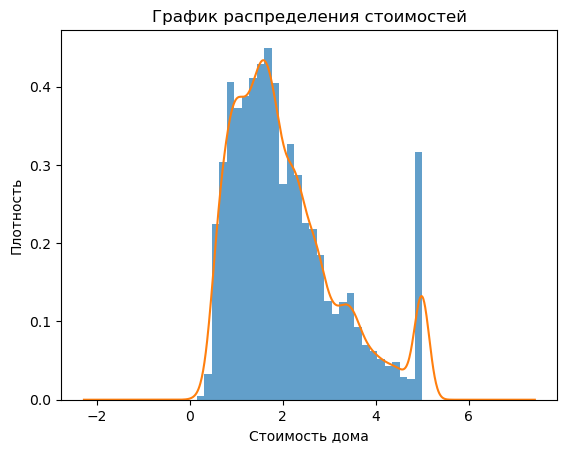

In [11]:
data["MedHouseVal"].hist(bins=30, density=True, alpha=0.7)
data["MedHouseVal"].plot.density()
plt.title("График распределения стоимостей")
plt.xlabel("Стоимость дома")
plt.ylabel("Плотность")
plt.show()

<Axes: >

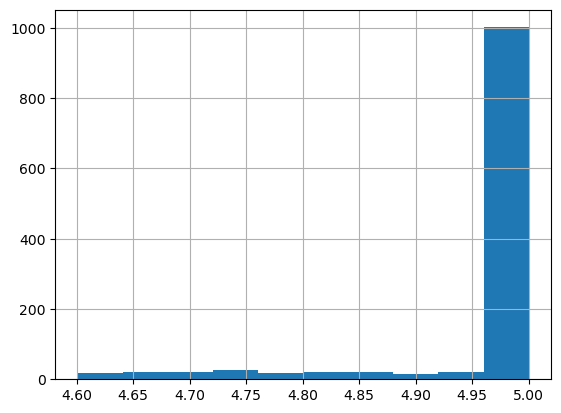

In [12]:
data[data["MedHouseVal"]>4.6].MedHouseVal.hist()

In [13]:
data[data["MedHouseVal"]>4.6].describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,1182.000000,1182.000000,1182.000000,1182.000000,1182.000000,1182.000000,1182.000000,1182.000000,1182.000000
mean,7.508004,33.681895,6.674824,1.091719,1126.328257,2.551297,35.216320,-119.684162,4.966177
std,3.161099,13.056264,4.279073,0.726735,814.058427,1.371093,1.792845,1.959398,0.088914
min,0.499900,2.000000,1.824719,0.500000,13.000000,1.275000,32.630000,-122.710000,4.601000
25%,5.081750,24.250000,5.379809,1.008305,648.000000,2.068849,33.952500,-122.120000,5.000010
50%,7.258300,34.000000,6.750235,1.051415,933.500000,2.507351,34.130000,-118.470000,5.000010
75%,9.775850,44.000000,7.750000,1.100336,1351.750000,2.841346,37.410000,-118.290000,5.000010
max,15.000100,52.000000,141.909091,25.636364,7431.000000,41.214286,38.910000,-116.430000,5.000010


#### Будем отдельно строить модель для данных с дорогими районами и без них

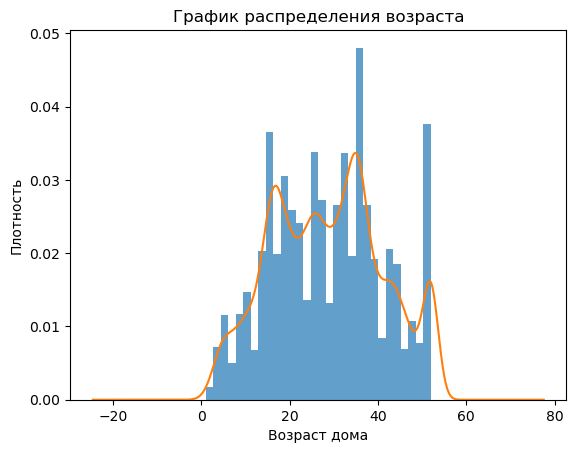

In [14]:
data["HouseAge"].hist(bins=30, density=True, alpha=0.7)
data["HouseAge"].plot.density()
plt.title("График распределения возраста")
plt.xlabel("Возраст дома")
plt.ylabel("Плотность")
plt.show()

<Axes: >

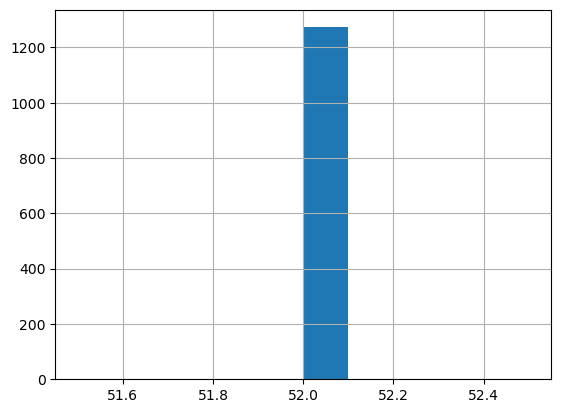

In [15]:
data[data["HouseAge"]>51].HouseAge.hist()

In [16]:
data[data["HouseAge"]>51].describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,1273.000000,1273.0,1273.000000,1273.000000,1273.000000,1273.000000,1273.000000,1273.000000,1273.000000
mean,3.889047,52.0,5.100120,1.066982,934.271013,2.840404,36.605161,-120.885915,2.754209
std,2.307418,0.0,1.399734,0.136465,529.536922,6.560677,1.919859,1.971172,1.390709
min,0.499900,52.0,1.260870,0.444444,8.000000,1.060606,32.660000,-124.350000,0.149990
25%,2.472200,52.0,4.263502,1.009597,591.000000,2.133333,34.120000,-122.410000,1.614000
50%,3.450000,52.0,4.952381,1.052227,879.000000,2.450085,37.750000,-122.220000,2.594000
75%,4.446400,52.0,5.760081,1.100917,1170.000000,2.873239,37.800000,-118.350000,3.804000
max,15.000100,52.0,12.901887,2.932075,6675.000000,230.172414,41.320000,-116.880000,5.000010


### **1.2.** Делим данные на тренировочный и тестовый наборы

In [17]:
data_train, data_test = train_test_split(data)
data_train.shape, data_test.shape

((15480, 9), (5160, 9))

In [18]:
corr_matrix = data_train.corr(method = 'pearson')
corr_matrix

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
MedInc,1.000000,-0.120303,0.306777,-0.057800,0.008267,0.024144,-0.079470,-0.014514,0.686446
HouseAge,-0.120303,1.000000,-0.150313,-0.078210,-0.293837,0.012521,0.008804,-0.108245,0.106214
AveRooms,0.306777,-0.150313,1.000000,0.863694,-0.073733,-0.008635,0.105714,-0.026147,0.141301
AveBedrms,-0.057800,-0.078210,0.863694,1.000000,-0.067474,-0.007070,0.072153,0.011169,-0.044875
Population,0.008267,-0.293837,-0.073733,-0.067474,1.000000,0.067761,-0.113325,0.103284,-0.017854
AveOccup,0.024144,0.012521,-0.008635,-0.007070,0.067761,1.000000,0.006973,0.000939,-0.026589
Latitude,-0.079470,0.008804,0.105714,0.072153,-0.113325,0.006973,1.000000,-0.926087,-0.142865
Longitude,-0.014514,-0.108245,-0.026147,0.011169,0.103284,0.000939,-0.926087,1.000000,-0.046496
MedHouseVal,0.686446,0.106214,0.141301,-0.044875,-0.017854,-0.026589,-0.142865,-0.046496,1.000000


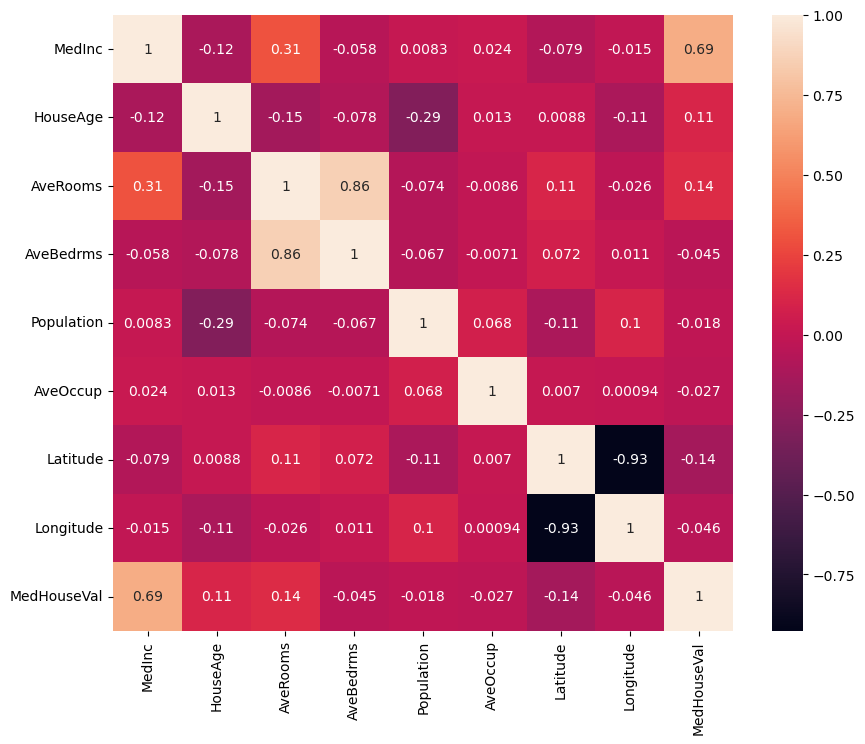

In [19]:
plt.figure(figsize = (10, 8))
sns.heatmap(corr_matrix, annot=True)
plt.show()

In [20]:
corr_matrix["MedHouseVal"].sort_values()

Latitude      -0.142865
Longitude     -0.046496
AveBedrms     -0.044875
AveOccup      -0.026589
Population    -0.017854
HouseAge       0.106214
AveRooms       0.141301
MedInc         0.686446
MedHouseVal    1.000000
Name: MedHouseVal, dtype: float64

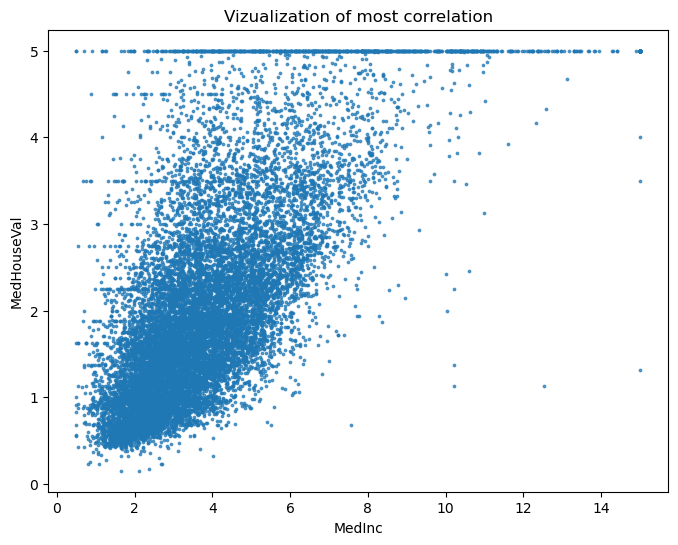

In [21]:
plt.figure(figsize = (8,6))
plt.scatter(data_train["MedInc"], data_train["MedHouseVal"], s=3, alpha=0.7)
plt.xlabel("MedInc")
plt.ylabel("MedHouseVal")
plt.title("Vizualization of most correlation")
plt.show()

In [22]:
data_train.isna().sum()

MedInc         0
HouseAge       0
AveRooms       0
AveBedrms      0
Population     0
AveOccup       0
Latitude       0
Longitude      0
MedHouseVal    0
dtype: int64

In [23]:
data_train.min()

MedInc           0.499900
HouseAge         1.000000
AveRooms         0.846154
AveBedrms        0.333333
Population       5.000000
AveOccup         0.692308
Latitude        32.540000
Longitude     -124.350000
MedHouseVal      0.149990
dtype: float64

In [24]:
data_train[(data_train["AveRooms"]<=1) | (data_train["AveBedrms"]<=1)]

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
2494,1.5536,25.0,4.088785,1.000000,931.0,4.350467,36.60,-120.19,0.583
10861,4.9153,17.0,5.203883,0.982201,1916.0,3.100324,33.70,-117.87,2.664
18946,6.6779,5.0,7.507177,0.952153,713.0,3.411483,38.30,-122.03,2.239
2110,2.5111,49.0,4.886792,0.964361,1290.0,2.704403,36.75,-119.75,0.554
726,4.3800,40.0,5.816479,0.947566,724.0,2.711610,37.68,-122.12,1.964
...,...,...,...,...,...,...,...,...,...
2745,3.6042,34.0,5.538462,1.000000,621.0,2.985577,32.79,-115.57,0.736
14635,3.7102,34.0,5.729508,0.909836,532.0,2.180328,32.80,-117.21,2.896
4214,2.1071,47.0,3.289474,0.858852,1512.0,3.617225,34.13,-118.27,2.089
5451,5.6428,43.0,4.980583,0.951456,266.0,2.582524,34.01,-118.46,3.431


In [25]:
data_train.columns.tolist()[:-1]

['MedInc',
 'HouseAge',
 'AveRooms',
 'AveBedrms',
 'Population',
 'AveOccup',
 'Latitude',
 'Longitude']

### **1.3.** Стандартизуем данные методом MinMaxScaler()

In [26]:
mm_scaler = MinMaxScaler()
data_train[data_train.columns.tolist()[:-1]] = mm_scaler.fit_transform(data_train[data_train.columns.tolist()[:-1]])
data_train.sort_index(inplace = True)
data_train

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,0.539668,0.784314,0.043512,0.020469,0.008885,0.001499,0.567481,0.215010,4.526
1,0.538027,0.392157,0.038224,0.018929,0.067158,0.001141,0.565356,0.216024,3.585
2,0.466028,1.000000,0.052756,0.021940,0.013762,0.001698,0.564293,0.213996,3.521
3,0.354699,1.000000,0.035241,0.021929,0.015500,0.001493,0.564293,0.212982,3.413
4,0.230776,1.000000,0.038534,0.022166,0.015696,0.001198,0.564293,0.212982,3.422
...,...,...,...,...,...,...,...,...,...
20635,0.073130,0.470588,0.029769,0.023715,0.023545,0.001503,0.737513,0.330629,0.781
20636,0.141853,0.333333,0.037344,0.029124,0.009838,0.001956,0.738576,0.318458,0.771
20637,0.082764,0.313725,0.030904,0.023323,0.028085,0.001314,0.732200,0.317444,0.923
20638,0.094295,0.333333,0.031783,0.024859,0.020630,0.001152,0.732200,0.307302,0.847


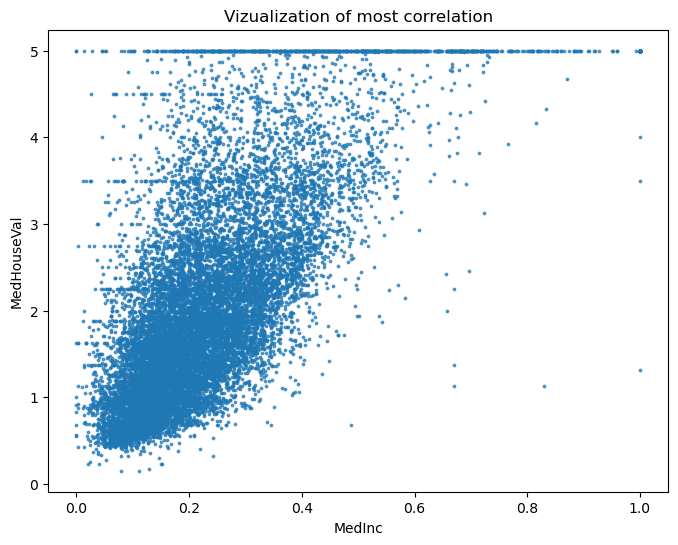

In [27]:
plt.figure(figsize = (8,6))
plt.scatter(data_train["MedInc"], data_train["MedHouseVal"], s=3, alpha=0.7)
plt.xlabel("MedInc")
plt.ylabel("MedHouseVal")
plt.title("Vizualization of most correlation")
plt.show()

In [28]:
data_test[data_test.columns.tolist()[:-1]] = mm_scaler.transform(data_test[data_test.columns.tolist()[:-1]])
data_test.sort_index(inplace = True)
data_test

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
13,0.149908,1.000000,0.022358,0.022659,0.009530,0.001038,0.563231,0.211968,1.913
14,0.097709,1.000000,0.024221,0.020050,0.033831,0.001016,0.564293,0.211968,1.592
18,0.102840,0.960784,0.031883,0.022310,0.027609,0.001344,0.563231,0.211968,1.587
24,0.144832,1.000000,0.031362,0.020817,0.028057,0.001361,0.563231,0.210953,1.326
37,0.062785,1.000000,0.020581,0.018807,0.025114,0.001242,0.562168,0.209939,1.039
...,...,...,...,...,...,...,...,...,...
20614,0.135833,0.490196,0.028041,0.018887,0.040642,0.001913,0.695005,0.284990,0.580
20617,0.193253,0.372549,0.028887,0.018463,0.008493,0.001617,0.692880,0.286004,0.708
20618,0.120695,0.470588,0.035783,0.022517,0.020209,0.002028,0.692880,0.283976,0.634
20629,0.109957,0.529412,0.033132,0.020382,0.193598,0.002502,0.699256,0.300203,1.083


## **2.** Строим модель Линейной регрессии 

### **2.1.** Создаем собственный класс **LinearRegres** для модели линейной регрессии и реализовываем два метода обучения: градиентный спуск и аналитический подход 

In [29]:
class LinearRegres:
    def init(model):
        pass

    def gradientdescent(model, X, iter_cost = 0.01, iterations = 300):
        y = np.array(X["MedHouseVal"])
        X = X.drop(columns = ["MedHouseVal"], axis = 1).to_numpy()
        model.weights, model.bias = np.zeros(X.shape[1]), 0
        costs = []

        for i in range(iterations + 1):
            costs.append((1 / X.shape[0]) * (np.sum((np.dot(X, model.weights) + model.bias - y) ** 2)))
            if i % 100 == 0:
                print(f"Cost at {i} iterations: {costs[-1]}")

            dJ_dw = (2 / X.shape[0]) * np.dot(X.T, (np.dot(X, model.weights) + model.bias - y))
            dJ_db = (2 / X.shape[0]) * np.sum(np.dot(X, model.weights) + model.bias - y)

            model.weights = model.weights - iter_cost * dJ_dw
            model.bias = model.bias - iter_cost * dJ_db

        return model.weights, model.bias, costs
    
    def analyt(model, X):
        y = np.array(X["MedHouseVal"])
        X = np.hstack((X.drop(columns = ["MedHouseVal"], axis = 1).to_numpy(), np.ones([X.shape[0], 1])))
        model.weights = np.dot(np.dot(np.linalg.inv(np.dot(X.T, X)), X.T), y)
        model.bias = model.weights[-1]
        model.weights = model.weights[0:-1]
        return model.weights, model.bias

    def R2_score(model, X):
        y_true = np.array(X["MedHouseVal"])
        y_pred = model.predict(X)
        return 1 - ((np.sum((y_true - y_pred) ** 2)) / (np.sum((y_true - np.mean(y_true)) ** 2)))

    def predict(model, X):
        X = X.drop(columns = ["MedHouseVal"], axis = 1).to_numpy()
        return np.dot(X, model.weights) + model.bias

    def funcloss(model, X):
        y = np.array(X["MedHouseVal"])
        return (1 / X.shape[0]) * (np.sum((model.predict(X) - y) ** 2))

### **2.2.** Обучаем модель аналитическим методом

In [30]:
hypplane_anal = LinearRegres()
weights, bias = hypplane_anal.analyt(data_train)
weights, bias

(array([  6.2431246 ,   0.47662613, -14.05885758,  20.24674508,
         -0.02122883,  -4.92104198,  -4.06302257,  -4.38849986]),
 np.float64(3.8291409727853587))

In [31]:
loses_on_train = []
loses_on_train.append(hypplane_anal.funcloss(data_train))
loses_on_train[-1]

np.float64(0.5248727715607858)

In [32]:
loses_on_test = []
loses_on_test.append(hypplane_anal.funcloss(data_test))
loses_on_test[-1]

np.float64(0.5232401338665181)

In [33]:
R2_list = []
R2_list.append(hypplane_anal.R2_score(data_test))
R2_list[-1]

np.float64(0.6081992861256933)

### **2.3.** Обучаем модель методом градиентного спуска

In [34]:
hypplane_grad = LinearRegres()
weights, bias, costs = hypplane_grad.gradientdescent(data_train, iter_cost = 0.5, iterations=1500)
weights, bias

Cost at 0 iterations: 5.626715862924547
Cost at 100 iterations: 0.6212310869553549
Cost at 200 iterations: 0.5803198552932957
Cost at 300 iterations: 0.5665374019536356
Cost at 400 iterations: 0.5577095366945221
Cost at 500 iterations: 0.5517362653843607
Cost at 600 iterations: 0.5476491200929621
Cost at 700 iterations: 0.5448208827912683
Cost at 800 iterations: 0.5428362547907168
Cost at 900 iterations: 0.5414195956682027
Cost at 1000 iterations: 0.5403876345579263
Cost at 1100 iterations: 0.5396182435996065
Cost at 1200 iterations: 0.5390298029782958
Cost at 1300 iterations: 0.5385675599467217
Cost at 1400 iterations: 0.538194607208126
Cost at 1500 iterations: 0.5378859128807378


(array([ 5.4860127 ,  0.512782  ,  0.42051214,  1.18528999,  0.16843435,
        -0.56841303, -4.10870737, -4.37482504]),
 np.float64(3.9389433514889793))

In [35]:
loses_on_train.append(hypplane_grad.funcloss(data_train))
loses_on_train[-1]

np.float64(0.5378830874109229)

In [36]:
loses_on_test.append(hypplane_grad.funcloss(data_test))
loses_on_test[-1]

np.float64(0.53768165321656)

In [37]:
R2_list.append(hypplane_grad.R2_score(data_test))
R2_list[-1]

np.float64(0.5973855177915166)

Text(0.5, 1.0, 'Gradient Descent')

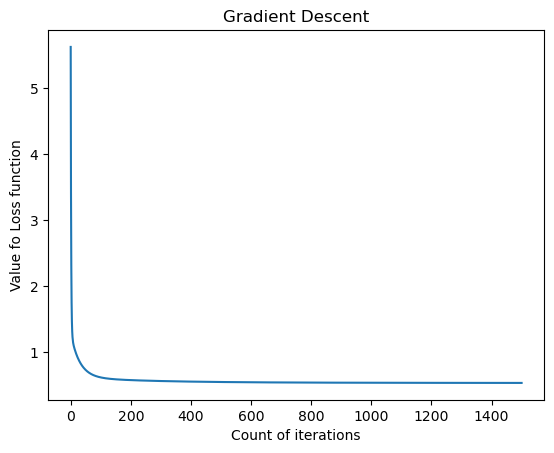

In [38]:
plt.plot(range(1501), costs)
plt.xlabel("Count of iterations")
plt.ylabel("Value fo Loss function")
plt.title("Gradient Descent")

### **2.4.** Обучаем модель при помощи библиотеки **sklearn**

In [39]:
hypplane_sklearn = LinearRegression().fit(data_train.drop(columns = "MedHouseVal", axis = 1), data_train["MedHouseVal"])
hypplane_sklearn.coef_, hypplane_sklearn.intercept_

(array([  6.2431246 ,   0.47662613, -14.05885758,  20.24674508,
         -0.02122883,  -4.92104198,  -4.06302257,  -4.38849986]),
 np.float64(3.8291409727848125))

In [40]:
loses_on_train.append((1/data_train.shape[0]) * np.sum((hypplane_sklearn.predict(data_train.drop(columns = "MedHouseVal", axis = 1)) - np.array(data_train["MedHouseVal"]))**2))
loses_on_train[-1]

np.float64(0.5248727715607858)

In [41]:
loses_on_test.append((1/data_test.shape[0]) * np.sum((hypplane_sklearn.predict(data_test.drop(columns = "MedHouseVal", axis = 1)) - np.array(data_test["MedHouseVal"]))**2))
loses_on_test[-1]

np.float64(0.5232401338665102)

In [42]:
y_true = np.array(data_test["MedHouseVal"])
y_pred = np.dot(data_test.drop(columns = ["MedHouseVal"], axis = 1).to_numpy(), hypplane_sklearn.coef_) + hypplane_sklearn.intercept_
R2_list.append(1 - (np.sum((y_true - y_pred) ** 2)) / (np.sum((y_true - np.mean(y_true)) ** 2)))
R2_list[-1]

np.float64(0.6081992861256991)

## **3.** Обучаем модель отдельно для дорогих и недорогих районов

### **3.1.** Обучаем модель для недорогих районов

#### **3.1.1.** Аналитический метод

In [43]:
data_train[data_train["MedHouseVal"]<4.6].count()

MedInc         14592
HouseAge       14592
AveRooms       14592
AveBedrms      14592
Population     14592
AveOccup       14592
Latitude       14592
Longitude      14592
MedHouseVal    14592
dtype: int64

In [44]:
Nonexp_data_train = data_train[data_train["MedHouseVal"]<4.6]
Nonexp_hypplane_anal = LinearRegres()
weights, bias = Nonexp_hypplane_anal.analyt(Nonexp_data_train)
weights, bias

(array([  5.94620589,   0.35839298, -14.02702668,  18.49731878,
          0.27809847,  -4.38646504,  -3.62103672,  -3.95631177]),
 np.float64(3.555791932471493))

In [45]:
loses_on_train.append(Nonexp_hypplane_anal.funcloss(Nonexp_data_train))
loses_on_train[-1]

np.float64(0.37645867913351627)

In [46]:
Nonexp_data_test = data_test[data_test["MedHouseVal"]<4.6]
loses_on_test.append(Nonexp_hypplane_anal.funcloss(Nonexp_data_test))
loses_on_test[-1]

np.float64(0.3654903080810588)

In [47]:
R2_list.append(Nonexp_hypplane_anal.R2_score(Nonexp_data_test))
R2_list[-1]

np.float64(0.5775941120255764)

#### **3.1.2.** Метод градиентного спуска

In [48]:
Nonexp_hypplane_grad = LinearRegres()
weights, bias, costs = Nonexp_hypplane_grad.gradientdescent(Nonexp_data_train, iter_cost = 0.5, iterations=1500)
weights, bias

Cost at 0 iterations: 4.469808515762074
Cost at 100 iterations: 0.47876433073267854
Cost at 200 iterations: 0.42348674433502104
Cost at 300 iterations: 0.40890203591669233
Cost at 400 iterations: 0.401585106604619
Cost at 500 iterations: 0.39692532372596745
Cost at 600 iterations: 0.3937935335053101
Cost at 700 iterations: 0.39165305009951473
Cost at 800 iterations: 0.39017133977133495
Cost at 900 iterations: 0.38913035321486183
Cost at 1000 iterations: 0.38838557006632646
Cost at 1100 iterations: 0.3878409206118317
Cost at 1200 iterations: 0.3874324138419466
Cost at 1300 iterations: 0.3871173267742622
Cost at 1400 iterations: 0.3868670506374112
Cost at 1500 iterations: 0.38666235380257097


(array([ 5.08251769,  0.37246995,  0.15857421,  0.84531463,  0.4122767 ,
        -0.51053398, -3.75573981, -4.03978967]),
 np.float64(3.7545316049365454))

In [49]:
loses_on_train.append(Nonexp_hypplane_grad.funcloss(Nonexp_data_train))
loses_on_train[-1]

np.float64(0.38666048901030253)

In [50]:
loses_on_test.append(Nonexp_hypplane_grad.funcloss(Nonexp_data_test))
loses_on_test[-1]

np.float64(0.37351562289338175)

In [51]:
R2_list.append(Nonexp_hypplane_grad.R2_score(Nonexp_data_test))
R2_list[-1]

np.float64(0.5683190638105584)

#### **3.1.3.** Библиотека **sklearn**

In [52]:
Nonexp_hypplane = LinearRegression().fit(Nonexp_data_train.drop(columns = "MedHouseVal", axis = 1), Nonexp_data_train["MedHouseVal"])
Nonexp_hypplane.coef_, Nonexp_hypplane.intercept_

(array([  5.94620589,   0.35839298, -14.02702668,  18.49731878,
          0.27809847,  -4.38646504,  -3.62103672,  -3.95631177]),
 np.float64(3.555791932471532))

In [53]:
loses_on_train.append((1/Nonexp_data_train.shape[0]) * np.sum((Nonexp_hypplane.predict(Nonexp_data_train.drop(columns = "MedHouseVal", axis = 1)) - np.array(Nonexp_data_train["MedHouseVal"]))**2))
loses_on_train[-1]

np.float64(0.37645867913351627)

In [54]:
loses_on_test.append((1/Nonexp_data_test.shape[0]) * np.sum((Nonexp_hypplane.predict(Nonexp_data_test.drop(columns = "MedHouseVal", axis = 1)) - np.array(Nonexp_data_test["MedHouseVal"]))**2))
loses_on_test[-1]

np.float64(0.36549030808105865)

In [55]:
y_true_Nonexp = np.array(Nonexp_data_test["MedHouseVal"])
y_pred_Nonexp = np.dot(Nonexp_data_test.drop(columns = ["MedHouseVal"], axis = 1).to_numpy(), Nonexp_hypplane.coef_) + Nonexp_hypplane.intercept_
R2_list.append(1 - (np.sum((y_true_Nonexp - y_pred_Nonexp) ** 2)) / (np.sum((y_true_Nonexp - np.mean(y_true_Nonexp)) ** 2)))
R2_list[-1]

np.float64(0.5775941120255765)

### **3.2.** Обучаем модель для дорогих районов

#### **3.2.1.** Аналитический метод

In [56]:
data_train[data_train["MedHouseVal"]>=4.6].count()

MedInc         888
HouseAge       888
AveRooms       888
AveBedrms      888
Population     888
AveOccup       888
Latitude       888
Longitude      888
MedHouseVal    888
dtype: int64

In [57]:
Exp_data_train = data_train[data_train["MedHouseVal"]>=4.6]
Exp_hypplane_anal = LinearRegres()
weights, bias = Exp_hypplane_anal.analyt(Exp_data_train)
weights, bias

(array([ 0.09539557,  0.02597024, -0.55000284,  0.99624198, -0.08662108,
        -0.06816931, -0.28203778, -0.26150517]),
 np.float64(5.107154106164101))

In [58]:
loses_on_train.append(Exp_hypplane_anal.funcloss(Exp_data_train))
loses_on_train[-1]

np.float64(0.00859162317606627)

In [59]:
Exp_data_test = data_test[data_test["MedHouseVal"]>=4.6]
loses_on_test.append(Exp_hypplane_anal.funcloss(Exp_data_test))
loses_on_test[-1]

np.float64(0.006060542480663362)

In [60]:
R2_list.append(Exp_hypplane_anal.R2_score(Exp_data_test))
R2_list[-1]

np.float64(0.0029740179981189163)

#### **3.2.2.** Метод градиентного спуска

In [61]:
Exp_hypplane_grad = LinearRegres()
weights, bias, costs = Exp_hypplane_grad.gradientdescent(Exp_data_train, iter_cost = 0.5, iterations=1500)
weights, bias

Cost at 0 iterations: 24.63751767575653
Cost at 100 iterations: 0.03391678827411005
Cost at 200 iterations: 0.010578997248674057
Cost at 300 iterations: 0.010385834230352112
Cost at 400 iterations: 0.010245792302665523
Cost at 500 iterations: 0.010128499919342074
Cost at 600 iterations: 0.010028096191313826
Cost at 700 iterations: 0.009940436142476477
Cost at 800 iterations: 0.009862566013956341
Cost at 900 iterations: 0.009792370399175273
Cost at 1000 iterations: 0.009728324473977715
Cost at 1100 iterations: 0.009669319978910984
Cost at 1200 iterations: 0.009614542972082366
Cost at 1300 iterations: 0.009563387924188376
Cost at 1400 iterations: 0.00951539732672461
Cost at 1500 iterations: 0.009470219212554577


(array([ 7.09147535e-02,  3.10506307e-02, -1.82132824e-01, -7.42935050e-02,
         8.90425810e-02, -5.63360151e-04,  8.77542594e-01,  8.49136777e-01]),
 np.float64(4.263173162833139))

In [62]:
loses_on_train.append(Exp_hypplane_grad.funcloss(Exp_data_train))
loses_on_train[-1]

np.float64(0.009469780647970853)

In [63]:
loses_on_test.append(Exp_hypplane_grad.funcloss(Exp_data_test))
loses_on_test[-1]

np.float64(0.007060754477098063)

In [64]:
R2_list.append(Exp_hypplane_grad.R2_score(Exp_data_test))
R2_list[-1]

np.float64(-0.16157187061451506)

#### **3.2.3.** Библиотека **sklearn**

In [65]:
Exp_hypplane = LinearRegression().fit(Exp_data_train.drop(columns = "MedHouseVal", axis = 1), Exp_data_train["MedHouseVal"])
Exp_hypplane.coef_, Exp_hypplane.intercept_

(array([ 0.09539557,  0.02597024, -0.55000284,  0.99624198, -0.08662108,
        -0.06816931, -0.28203778, -0.26150517]),
 np.float64(5.107154106164035))

In [66]:
loses_on_train.append((1/Exp_data_train.shape[0]) * np.sum((Exp_hypplane.predict(Exp_data_train.drop(columns = "MedHouseVal", axis = 1)) - np.array(Exp_data_train["MedHouseVal"]))**2))
loses_on_train[-1]

np.float64(0.008591623176066274)

In [67]:
loses_on_test.append((1/Exp_data_test.shape[0]) * np.sum((Exp_hypplane.predict(Exp_data_test.drop(columns = "MedHouseVal", axis = 1)) - np.array(Exp_data_test["MedHouseVal"]))**2))
loses_on_test[-1]

np.float64(0.006060542480670007)

In [68]:
y_true_Exp = np.array(Exp_data_test["MedHouseVal"])
y_pred_Exp = np.dot(Exp_data_test.drop(columns = ["MedHouseVal"], axis = 1).to_numpy(), Exp_hypplane.coef_) + Exp_hypplane.intercept_
R2_list.append(1 - (np.sum((y_true_Exp - y_pred_Exp) ** 2)) / (np.sum((y_true_Exp - np.mean(y_true_Exp)) ** 2)))
R2_list[-1]

np.float64(0.0029740179970257907)

In [69]:
(1/Exp_data_test.shape[0]) * (np.sum((Exp_data_train["MedHouseVal"].mean() - Exp_data_test["MedHouseVal"])**2))  #!!!

np.float64(0.006180312439607228)

In [70]:
(1 - np.sum((Exp_data_test["MedHouseVal"] - Exp_data_train["MedHouseVal"].mean()) ** 2)) / np.sum((Exp_data_test["MedHouseVal"] - np.mean(Exp_data_test["MedHouseVal"])) ** 2)

np.float64(-0.4628203250347729)

## 4. Выводы

In [71]:
loses_on_train

[np.float64(0.5248727715607858),
 np.float64(0.5378830874109229),
 np.float64(0.5248727715607858),
 np.float64(0.37645867913351627),
 np.float64(0.38666048901030253),
 np.float64(0.37645867913351627),
 np.float64(0.00859162317606627),
 np.float64(0.009469780647970853),
 np.float64(0.008591623176066274)]

In [72]:
loses_on_test

[np.float64(0.5232401338665181),
 np.float64(0.53768165321656),
 np.float64(0.5232401338665102),
 np.float64(0.3654903080810588),
 np.float64(0.37351562289338175),
 np.float64(0.36549030808105865),
 np.float64(0.006060542480663362),
 np.float64(0.007060754477098063),
 np.float64(0.006060542480670007)]

In [73]:
R2_list

[np.float64(0.6081992861256933),
 np.float64(0.5973855177915166),
 np.float64(0.6081992861256991),
 np.float64(0.5775941120255764),
 np.float64(0.5683190638105584),
 np.float64(0.5775941120255765),
 np.float64(0.0029740179981189163),
 np.float64(-0.16157187061451506),
 np.float64(0.0029740179970257907)]

In [74]:
table = pd.DataFrame(data = [loses_on_train, loses_on_test, R2_list], index = ["MSE on train", "MSE on test", "R2 on test"], columns = ["Analyt All", "Gradient All", "Sklearn All", "Analyt Nonexp", "Gradient Nonexp", "Sklearn Nonexp", "Analyt Exp", "Gradient Exp", "Sklearn Exp"])
table

,Analyt All,Gradient All,Sklearn All,Analyt Nonexp,Gradient Nonexp,Sklearn Nonexp,Analyt Exp,Gradient Exp,Sklearn Exp
MSE on train,0.524873,0.537883,0.524873,0.376459,0.386660,0.376459,0.008592,0.009470,0.008592
MSE on test,0.523240,0.537682,0.523240,0.365490,0.373516,0.365490,0.006061,0.007061,0.006061
R2 on test,0.608199,0.597386,0.608199,0.577594,0.568319,0.577594,0.002974,-0.161572,0.002974


* Реализованный собственноручно аналитический подход к обучению модели полностью идентичен предложенный библиотекой sklearn;
* Во всех трёх сформированных датасетах (все дома, только дорогие, только недорогие) метод обучения градиентным спуском приводит к более лучшей функции потерь по сравнении с аналитическим подходом (тот же Linear Regression из sklearn). Исключением является лишь небольшой датасет (всего 893 элемента в обучающей выборке) с дорогими домами, в котором аналитический подход дал не намного, но лучше показатели;
* Модель построенная тремя подходами (фактически двумя) во всех трёх случаях показала себя на тренировочной выборке лучше чем на тестовой выборке, то есть на выборке, которую она еще не видела (что вполне закономерно);
* Разделение исходного датасета на два датасета по критерию дороговизны дома (что было решено на основе графика распределения стоимости домов на всём наборе данных) привёл к заметному улучшению качества оценки модели;
* Модель обученная на данных для дорогих домов показала фантастические результаты на по метрике MSE (минимальная квадратичная ошибка), но достаточно печальные по метрике R2, что является закономерным следствием маленького обьема данных (893 элемента на тренировочном наборе) и ничтожным разнообразием цен домов (фактически цены варьируются от 4.6 до 5.1, а стандартное отклонение составляет ничтожные 0.089). Это непосредственно означает, что модели попросту нечего оценивать, целевая переменная почти константа, и ничего бы не стоило (а даже было бы качественнее 0.0093 < 0.0097) заменить нашу модель на постоянное предсказание среднего значения на данной выборке